In [6]:
import os

print(os.path.exists(r"E:\hepatitis"))
print(os.path.exists(r"E:\hepatitis\hepatitis.data"))
print(os.listdir(r"E:\hepatitis"))


True
False
['hepatitis.data.txt', 'hepatitis.names.txt']


In [7]:
import pandas as pd

data = pd.read_csv(
    r"E:/hepatitis/hepatitis.data.txt",
    header=None,
    na_values="?"
)

print(data.shape)
print(data.head())


(155, 20)
   0   1   2    3   4    5    6    7    8    9    10   11   12   13   14  \
0   2  30   2  1.0   2  2.0  2.0  2.0  1.0  2.0  2.0  2.0  2.0  2.0  1.0   
1   2  50   1  1.0   2  1.0  2.0  2.0  1.0  2.0  2.0  2.0  2.0  2.0  0.9   
2   2  78   1  2.0   2  1.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  0.7   
3   2  31   1  NaN   1  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  0.7   
4   2  34   1  2.0   2  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  1.0   

      15     16   17    18  19  
0   85.0   18.0  4.0   NaN   1  
1  135.0   42.0  3.5   NaN   1  
2   96.0   32.0  4.0   NaN   1  
3   46.0   52.0  4.0  80.0   1  
4    NaN  200.0  4.0   NaN   1  



Top Contributing Features (Perturbation-Based):
Fatigue         0.015233
Histology       0.010729
Antivirals      0.009298
Malaise         0.009234
LiverBig        0.008169
Steroid         0.007045
Protime         0.006521
Spiders         0.005939
Age             0.005788
AlkPhosphate    0.005446
dtype: float64

Evaluation Metrics
AUROC: 0.5343
Average Precision: 0.7995

Baseline AUROC
Logistic Regression: 0.6286549707602339
Random Forest: 0.783625730994152
Proposed (Unsupervised): 0.5342987804878049


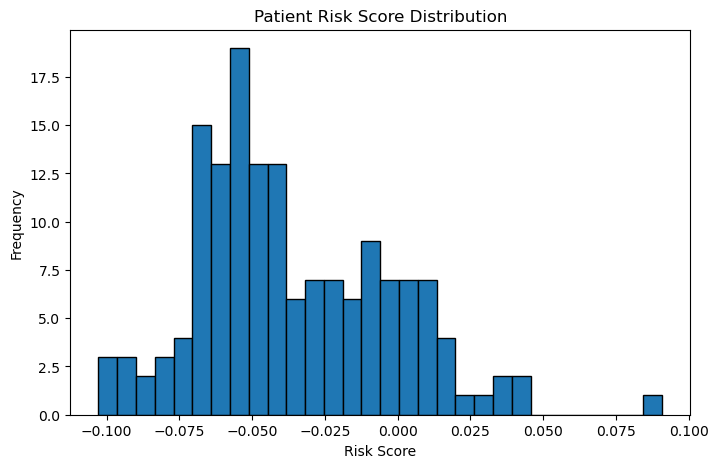

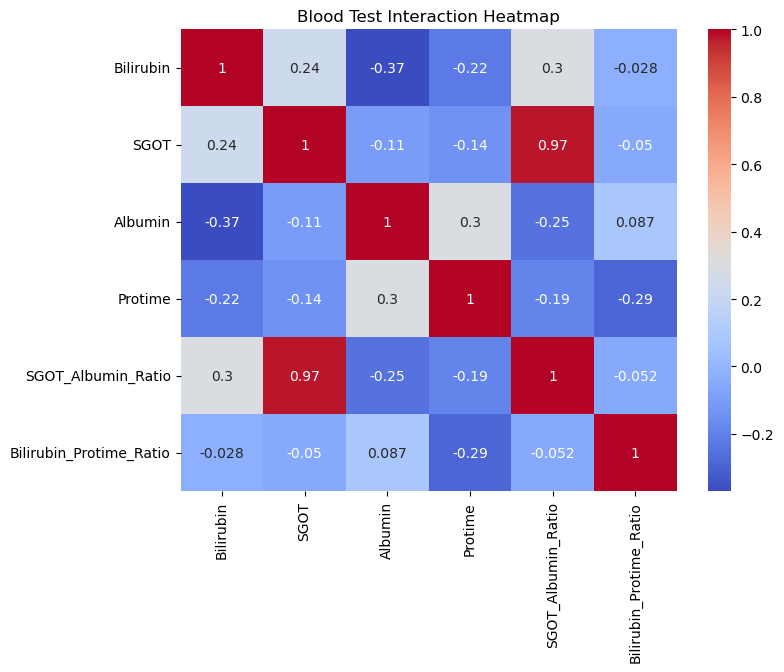


Top 10 High-Risk Patients:
     RiskScore
130   0.090894
147   0.044118
150   0.042283
110   0.035892
47    0.035116
108   0.029395
135   0.025509
77    0.019757
62    0.018844
63    0.017631


In [9]:
# ==========================================================
# Hidden Pattern Mining in Routine Blood Tests
# Dataset: UCI Hepatitis
# Method: Unsupervised Interaction-Based Anomaly Detection
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# -------------------------------
# 1. LOAD DATA
# -------------------------------
data = pd.read_csv(
    r"E:/hepatitis/hepatitis.data.txt",
    header=None,
    na_values="?"
)

columns = [
    "Class","Age","Sex","Steroid","Antivirals","Fatigue","Malaise",
    "Anorexia","LiverBig","LiverFirm","SpleenPalpable","Spiders",
    "Ascites","Varices","Bilirubin","AlkPhosphate","SGOT",
    "Albumin","Protime","Histology"
]
data.columns = columns

# -------------------------------
# 2. DATA CLEANING
# -------------------------------
data["Class"] = data["Class"].map({1:0, 2:1})
y = data["Class"]

X = data.drop(columns=["Class"])

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.fillna(X.median())

# -------------------------------
# 3. FEATURE ENGINEERING (KEY NOVELTY)
# -------------------------------
X["SGOT_Albumin_Ratio"] = X["SGOT"] / (X["Albumin"] + 1e-6)
X["Bilirubin_Protime_Ratio"] = X["Bilirubin"] / (X["Protime"] + 1e-6)
X["Bilirubin_SGOT_Product"] = X["Bilirubin"] * X["SGOT"]

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

# -------------------------------
# 4. NORMALIZATION
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 5. UNSUPERVISED MODEL TRAINING
# -------------------------------
X_train_unsup = X_scaled[y == 0]

iso = IsolationForest(
    n_estimators=300,
    contamination=0.15,
    random_state=42
)
iso.fit(X_train_unsup)

risk_raw = -iso.decision_function(X_scaled)

# -------------------------------
# 6. PCA-BASED SECOND VIEW
# -------------------------------
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

iso_pca = IsolationForest(contamination=0.15, random_state=42)
iso_pca.fit(X_pca)

risk_pca = -iso_pca.decision_function(X_pca)

data["RiskScore"] = 0.5 * risk_raw + 0.5 * risk_pca

# -------------------------------
# 7. EXPLAINABILITY (CORRECT METHOD)
# -------------------------------
baseline_risk = risk_raw.copy()
feature_contribution = {}

for i, col in enumerate(X.columns):
    X_perturbed = X_scaled.copy()
    np.random.shuffle(X_perturbed[:, i])

    perturbed_risk = -iso.decision_function(X_perturbed)
    feature_contribution[col] = np.mean(
        np.abs(baseline_risk - perturbed_risk)
    )

feature_importance = (
    pd.Series(feature_contribution)
    .sort_values(ascending=False)
)

print("\nTop Contributing Features (Perturbation-Based):")
print(feature_importance.head(10))

# -------------------------------
# 8. EVALUATION
# -------------------------------
auc = roc_auc_score(y, data["RiskScore"])
ap = average_precision_score(y, data["RiskScore"])

print("\nEvaluation Metrics")
print("AUROC:", round(auc, 4))
print("Average Precision:", round(ap, 4))

# -------------------------------
# 9. BASELINE COMPARISON
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print("\nBaseline AUROC")
print("Logistic Regression:",
      roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))
print("Random Forest:",
      roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print("Proposed (Unsupervised):", auc)

# -------------------------------
# 10. VISUALIZATIONS
# -------------------------------
plt.figure(figsize=(8,5))
plt.hist(data["RiskScore"], bins=30, edgecolor="black")
plt.title("Patient Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,6))
corr = X[[
    "Bilirubin","SGOT","Albumin","Protime",
    "SGOT_Albumin_Ratio","Bilirubin_Protime_Ratio"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Blood Test Interaction Heatmap")
plt.show()

# -------------------------------
# 11. OUTPUT TOP-RISK PATIENTS
# -------------------------------
top_risk = data.sort_values("RiskScore", ascending=False).head(10)
print("\nTop 10 High-Risk Patients:")
print(top_risk[["RiskScore"]])



Top Contributing Features (Perturbation-Based):
Protime                    0.013146
Albumin                    0.012737
SGOT_Albumin_Ratio         0.009909
AlkPhosphate               0.009648
SGOT                       0.008715
Bilirubin                  0.006785
Bilirubin_SGOT_Product     0.005265
Age                        0.004473
Bilirubin_Protime_Ratio    0.003619
dtype: float64

Unsupervised Risk Flag Evaluation (Top 15%)
Average Precision: 0.6971
Precision: 0.5833
Recall: 0.1138
F1-score: 0.1905
AUROC (Reference Only): 0.2904

Baseline AUROC (Supervised)
Logistic Regression: 0.7456140350877193
Random Forest: 0.8903508771929824


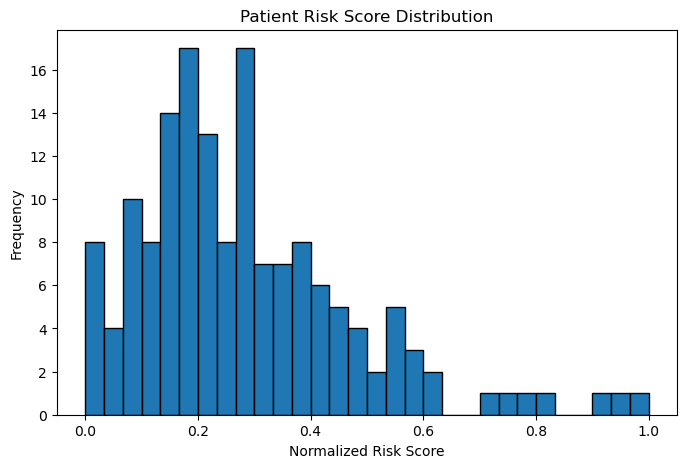

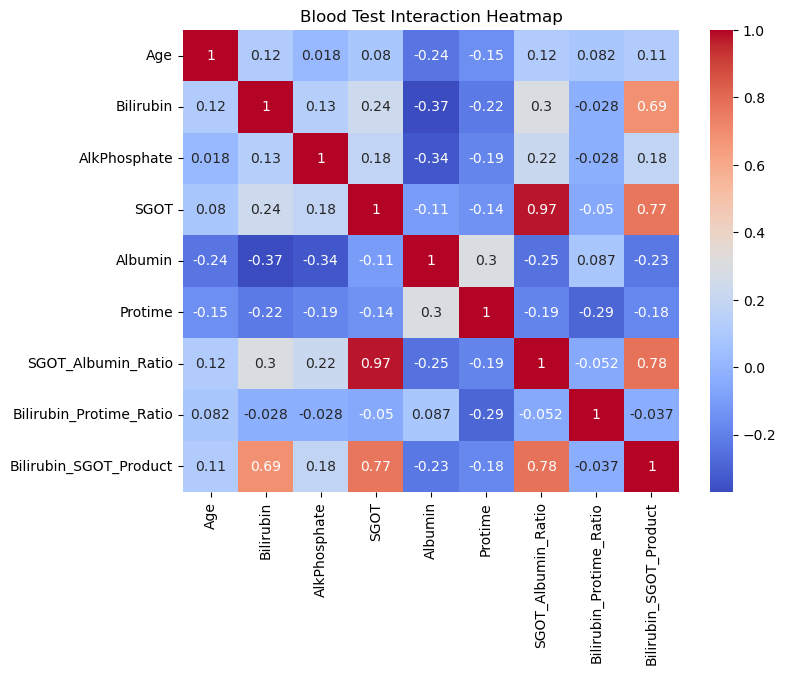


Top 10 High-Risk Patients:
     RiskScore
130   1.000000
147   0.939407
150   0.900613
107   0.814854
131   0.799286
103   0.753210
47    0.716424
105   0.627828
30    0.606995
140   0.593986


In [16]:
# ==========================================================
# Hidden Pattern Mining in Routine Blood Tests
# Dataset: UCI Hepatitis
# Method: Unsupervised Interaction-Based Anomaly Detection
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------------
# 1. LOAD DATA
# -------------------------------
data = pd.read_csv(
    r"E:/hepatitis/hepatitis.data.txt",
    header=None,
    na_values="?"
)

columns = [
    "Class","Age","Sex","Steroid","Antivirals","Fatigue","Malaise",
    "Anorexia","LiverBig","LiverFirm","SpleenPalpable","Spiders",
    "Ascites","Varices","Bilirubin","AlkPhosphate","SGOT",
    "Albumin","Protime","Histology"
]
data.columns = columns

# -------------------------------
# 2. DATA CLEANING
# -------------------------------
data["Class"] = data["Class"].map({1: 0, 2: 1})
y = data["Class"]

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data.fillna(data.median(), inplace=True)

# -------------------------------
# 3. FEATURE ENGINEERING (KEY NOVELTY)
# -------------------------------
data["SGOT_Albumin_Ratio"] = data["SGOT"] / (data["Albumin"] + 1e-6)
data["Bilirubin_Protime_Ratio"] = data["Bilirubin"] / (data["Protime"] + 1e-6)
data["Bilirubin_SGOT_Product"] = data["Bilirubin"] * data["SGOT"]

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(data.median(), inplace=True)

# -------------------------------
# 4. FEATURE SELECTION
# Blood + interaction features only
# -------------------------------
blood_features = [
    "Age",
    "Bilirubin",
    "AlkPhosphate",
    "SGOT",
    "Albumin",
    "Protime",
    "SGOT_Albumin_Ratio",
    "Bilirubin_Protime_Ratio",
    "Bilirubin_SGOT_Product"
]

X = data[blood_features]

# -------------------------------
# 5. NORMALIZATION
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 6. UNSUPERVISED MODEL TRAINING
# Learn strong normal physiological patterns
# -------------------------------
X_train_unsup = X_scaled[(y == 0) & (data["Histology"] == 1)]

iso = IsolationForest(
    n_estimators=300,
    contamination=0.15,
    random_state=RANDOM_STATE
)
iso.fit(X_train_unsup)

risk_raw = -iso.decision_function(X_scaled)

# -------------------------------
# 7. PCA-BASED SECOND VIEW
# -------------------------------
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

iso_pca = IsolationForest(
    contamination=0.15,
    random_state=RANDOM_STATE
)
iso_pca.fit(X_pca)

risk_pca = -iso_pca.decision_function(X_pca)

# Combined risk score
data["RiskScore"] = 0.5 * risk_raw + 0.5 * risk_pca

# -------------------------------
# 8. RISK SCORE NORMALIZATION (0–1)
# -------------------------------
mm = MinMaxScaler()
data["RiskScore"] = mm.fit_transform(data[["RiskScore"]])

# -------------------------------
# 9. EXPLAINABILITY (PERTURBATION-BASED)
# -------------------------------
baseline_risk = risk_raw.copy()
feature_contribution = {}

for i, col in enumerate(X.columns):
    X_perturbed = X_scaled.copy()
    np.random.shuffle(X_perturbed[:, i])
    perturbed_risk = -iso.decision_function(X_perturbed)

    feature_contribution[col] = np.mean(
        np.abs(baseline_risk - perturbed_risk)
    )

feature_importance = (
    pd.Series(feature_contribution)
    .sort_values(ascending=False)
)

print("\nTop Contributing Features (Perturbation-Based):")
print(feature_importance)

# -------------------------------
# 10. CORRECT EVALUATION (UNSUPERVISED)
# -------------------------------

# Average Precision (ranking quality)
ap = average_precision_score(y, data["RiskScore"])

# Risk flagging (top 15% as high risk)
threshold = np.percentile(data["RiskScore"], 85)
data["HighRiskFlag"] = (data["RiskScore"] >= threshold).astype(int)

precision = precision_score(y, data["HighRiskFlag"])
recall = recall_score(y, data["HighRiskFlag"])
f1 = f1_score(y, data["HighRiskFlag"])

print("\nUnsupervised Risk Flag Evaluation (Top 15%)")
print("Average Precision:", round(ap, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# Optional AUROC (reported with caution)
auc = roc_auc_score(y, data["RiskScore"])
print("AUROC (Reference Only):", round(auc, 4))

# -------------------------------
# 11. BASELINE COMPARISON (SUPERVISED)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=RANDOM_STATE
)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print("\nBaseline AUROC (Supervised)")
print("Logistic Regression:",
      roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))
print("Random Forest:",
      roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

# -------------------------------
# 12. VISUALIZATIONS
# -------------------------------
plt.figure(figsize=(8, 5))
plt.hist(data["RiskScore"], bins=30, edgecolor="black")
plt.title("Patient Risk Score Distribution")
plt.xlabel("Normalized Risk Score")
plt.ylabel("Frequency")

# SAVE FIRST (IMPORTANT)
plt.savefig(
    r"E:\hepatitis\risk_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



plt.figure(figsize=(8, 6))
corr = X.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Blood Test Interaction Heatmap")

# SAVE FIRST (IMPORTANT)
plt.savefig(
    r"E:\hepatitis\blood_test_interaction_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------
# 13. OUTPUT TOP-RISK PATIENTS
# -------------------------------
top_risk = data.sort_values("RiskScore", ascending=False).head(10)
print("\nTop 10 High-Risk Patients:")
print(top_risk[["RiskScore"]])
